<a href="https://colab.research.google.com/github/WanjaWhoopie/ABDN-Fellowship/blob/main/Whoopie's_Copy_of_EEG_Session14_TimeFrequency_PSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ABDN EEG Fellowship: Session 14
## Time-Frequency Analysis: Fourier Transform & Power Spectra

---

### What we're doing today

Last session we built a clean preprocessing pipeline and saved epochs.
Today we ask: **what frequencies are in our EEG signal, and when?**

We'll go from the simplest possible sine wave → Fourier transform → real EEG power spectra in MNE.

## Setup: run this first, every session



In [ ]:
!pip install mne --quiet --upgrade moviepy jedi mne

import mne
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
mne.set_log_level('WARNING')
print(f'MNE version: {mne.__version__}')

MNE version: 1.12.1


---
## Part A: Why Frequency?

When we plot raw EEG in the **time domain**, we see a wiggly line.
It's hard to answer: *is there more alpha today than yesterday? Is theta elevated during the task?*

The **frequency domain** answers those questions directly.
The key insight: **both representations contain the same information**, only organised in a different way.

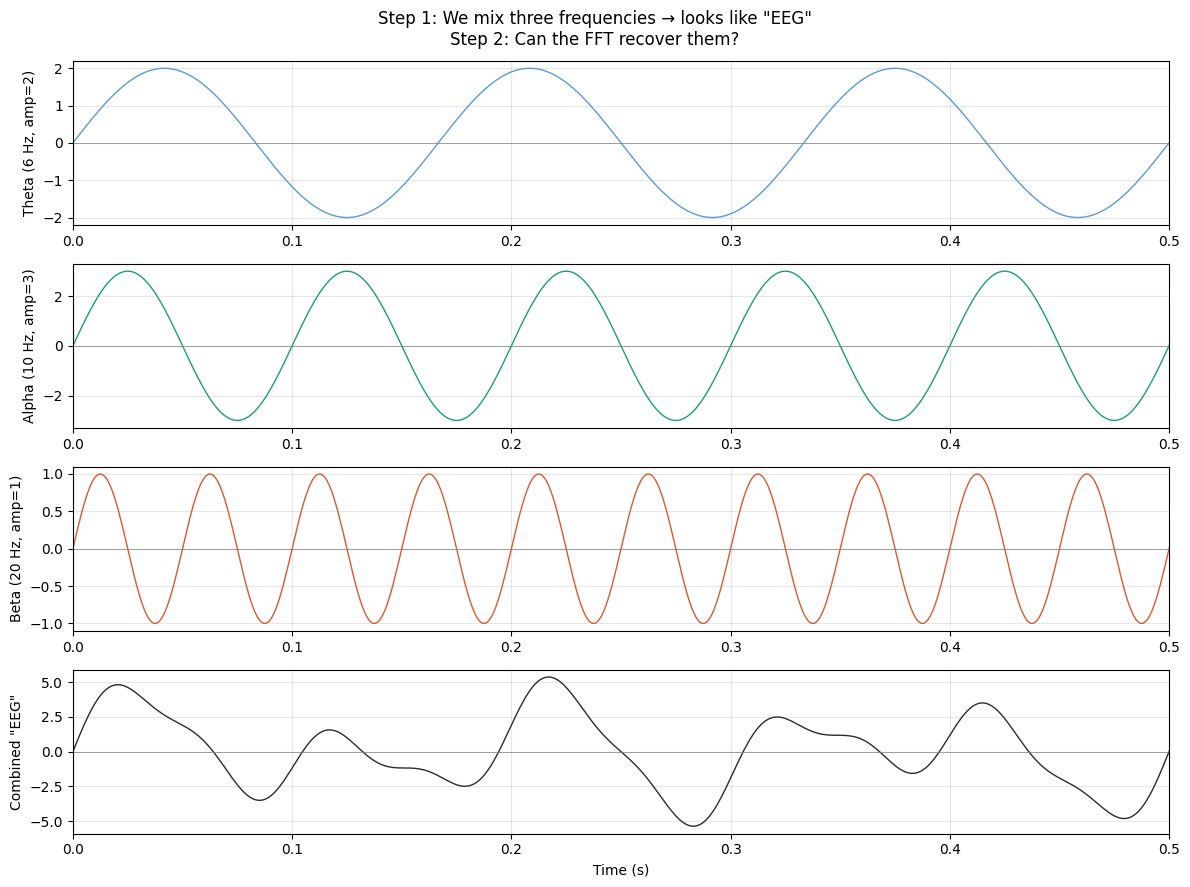

Look at the bottom panel can you see the three rhythms mixed together?
This is exactly what your EEG looks like. Multiple frequencies..chaos


In [ ]:
# We build a signal from scratch
# We'll mix three sine waves and then show that the FFT recovers them

sfreq = 1000          # 1000 Hz sampling rate
duration = 2          # 2 seconds
t = np.linspace(0, duration, sfreq * duration, endpoint=False)

# Three components: theta (6 Hz), alpha (10 Hz), beta (20 Hz)
theta = 2.0 * np.sin(2 * np.pi * 6  * t)   # amplitude 2
alpha = 3.0 * np.sin(2 * np.pi * 10 * t)   # amplitude 3  ← strongest
beta  = 1.0 * np.sin(2 * np.pi * 20 * t)   # amplitude 1

signal = theta + alpha + beta               # this is our "EEG"

fig, axes = plt.subplots(4, 1, figsize=(12, 9))

for ax, wave, label, color in zip(
    axes[:3],
    [theta, alpha, beta],
    ['Theta (6 Hz, amp=2)', 'Alpha (10 Hz, amp=3)', 'Beta (20 Hz, amp=1)'],
    ['#5B9BD5', '#1D9E75', '#D85A30']
):
    ax.plot(t, wave, color=color, linewidth=1)
    ax.set_ylabel(label, fontsize=10)
    ax.set_xlim(0, 0.5)  # show first 0.5 s
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.grid(True, alpha=0.3)

axes[3].plot(t, signal, color='#2C2C2A', linewidth=1)
axes[3].set_ylabel('Combined "EEG"', fontsize=10)
axes[3].set_xlabel('Time (s)')
axes[3].set_xlim(0, 0.5)
axes[3].axhline(0, color='gray', linewidth=0.5)
axes[3].grid(True, alpha=0.3)

fig.suptitle('Step 1: We mix three frequencies → looks like "EEG"\nStep 2: Can the FFT recover them?', fontsize=12)
plt.tight_layout()
plt.show()

print('Look at the bottom panel can you see the three rhythms mixed together?')
print('This is exactly what your EEG looks like. Multiple frequencies..chaos')

---
## Part B: The Fourier Transform

### The core idea

The Fourier transform asks: *"If I fit a sine wave of frequency f to this signal, how well does it match?"*

It does this for every frequency from 0 Hz up to the Nyquist limit (sfreq/2).
The magnitude tells you **how much power**, the angle tells you **the phase**.

**Power spectrum** = magnitude² at each frequency.

### Two important limits you must know

| Property | Formula | Example |
|---|---|---|
| **Frequency resolution** | 1 / signal duration | 2 s signal → 0.5 Hz resolution |
| **Max frequency (Nyquist)** | sfreq / 2 | 1000 Hz sampling → up to 500 Hz |

Longer signal = better frequency resolution, less time resolution. **This is the trade-off.**

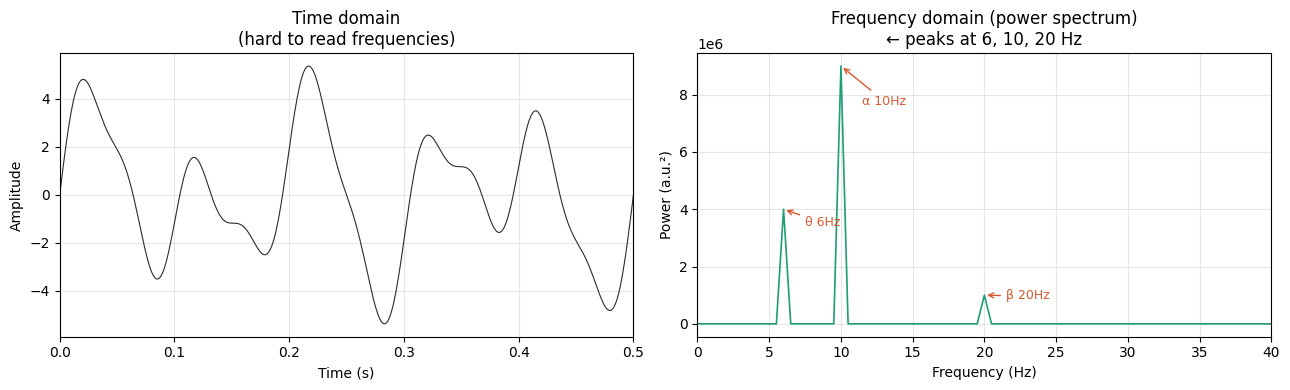

Peaks recovered by FFT:
  6 Hz → power ≈ 4000000  (amplitude was 2.0, amp² ≈ 4)
  10 Hz → power ≈ 9000000  (amplitude was 3.0, amp² ≈ 9)
  20 Hz → power ≈ 1000000  (amplitude was 1.0, amp² ≈ 1)

The FFT perfectly recovered all three frequencies from the messy combined signal.
This is exactly what we do with EEG, we extract the hidden rhythms.


In [ ]:
# Apply the FFT to our signal and recover the frequencies

# Compute FFT
fft_result = np.fft.rfft(signal)           # rfft = real-valued FFT (half spectrum)
freqs      = np.fft.rfftfreq(len(signal), d=1/sfreq)  # frequency axis

# Power = magnitude squared
power = np.abs(fft_result) ** 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Time domain
ax1.plot(t, signal, color='#2C2C2A', linewidth=0.8)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Time domain\n(hard to read frequencies)')
ax1.set_xlim(0, 0.5)
ax1.grid(True, alpha=0.3)

# Frequency domain
ax2.plot(freqs, power, color='#1D9E75', linewidth=1.2)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Power (a.u.²)')
ax2.set_title('Frequency domain (power spectrum)\n← peaks at 6, 10, 20 Hz')
ax2.set_xlim(0, 40)
ax2.grid(True, alpha=0.3)

# Annotate the peaks
for freq, label in [(6, 'θ 6Hz'), (10, 'α 10Hz'), (20, 'β 20Hz')]:
    idx = np.argmin(np.abs(freqs - freq))
    ax2.annotate(label, xy=(freq, power[idx]),
                 xytext=(freq + 1.5, power[idx] * 0.85),
                 fontsize=9, color='#D85A30',
                 arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1))

plt.tight_layout()
plt.show()

# Check: power should be proportional to amplitude²
print('Peaks recovered by FFT:')
for freq, expected_amp in [(6, 2.0), (10, 3.0), (20, 1.0)]:
    idx = np.argmin(np.abs(freqs - freq))
    print(f'  {freq} Hz → power ≈ {power[idx]:.0f}  (amplitude was {expected_amp}, amp² ≈ {expected_amp**2:.0f})')
print()
print('The FFT perfectly recovered all three frequencies from the messy combined signal.')
print('This is exactly what we do with EEG, we extract the hidden rhythms.')

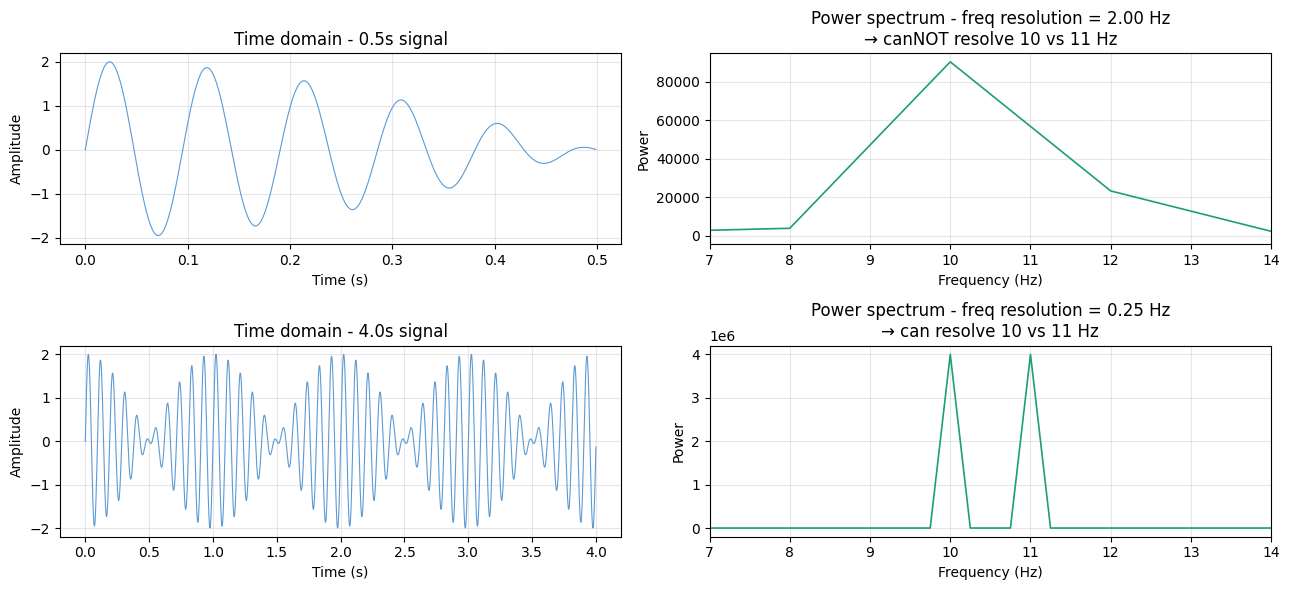

KEY INSIGHT:
  Short signal (0.5 s) → freq resolution = 2 Hz → 10 and 11 Hz blur together
  Long signal (4.0 s)  → freq resolution = 0.25 Hz → 10 and 11 Hz clearly separated

  This is why EEG epochs need to be long enough for the frequency you want to measure.
  For theta (4–8 Hz), you need at least 0.25–0.5 s epochs.
  For delta (1–4 Hz), you need at least 1–2 s.


In [ ]:
# Demonstrate the frequency resolution trade-off

# Two signals: one short (0.5 s), one long (4 s)
# Both contain a 10 Hz and 11 Hz component,, can the FFT tell them apart?

fig, axes = plt.subplots(2, 2, figsize=(13, 6))

for row, dur in enumerate([0.5, 4.0]):
    t_test = np.linspace(0, dur, int(sfreq * dur), endpoint=False)
    sig_test = (np.sin(2 * np.pi * 10 * t_test) +
                np.sin(2 * np.pi * 11 * t_test))

    freqs_test = np.fft.rfftfreq(len(sig_test), d=1/sfreq)
    power_test = np.abs(np.fft.rfft(sig_test)) ** 2

    freq_res = 1 / dur

    axes[row, 0].plot(t_test, sig_test, color='#5B9BD5', linewidth=0.8)
    axes[row, 0].set_title(f'Time domain - {dur}s signal')
    axes[row, 0].set_xlabel('Time (s)')
    axes[row, 0].set_ylabel('Amplitude')
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(freqs_test, power_test, color='#1D9E75', linewidth=1.2)
    axes[row, 1].set_title(f'Power spectrum - freq resolution = {freq_res:.2f} Hz\n→ can{" " if dur >= 2 else "NOT "}resolve 10 vs 11 Hz')
    axes[row, 1].set_xlabel('Frequency (Hz)')
    axes[row, 1].set_ylabel('Power')
    axes[row, 1].set_xlim(7, 14)
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('KEY INSIGHT:')
print('  Short signal (0.5 s) → freq resolution = 2 Hz → 10 and 11 Hz blur together')
print('  Long signal (4.0 s)  → freq resolution = 0.25 Hz → 10 and 11 Hz clearly separated')
print()
print('  This is why EEG epochs need to be long enough for the frequency you want to measure.')
print('  For theta (4–8 Hz), you need at least 0.25–0.5 s epochs.')
print('  For delta (1–4 Hz), you need at least 1–2 s.')

### The non-stationarity problem

The FFT assumes the signal is **stationary**. which means the same frequencies are present throughout.
But EEG is not stationary. Alpha appears when eyes close. Theta spikes during memory load. Beta disappears during movement.

A single FFT over the whole recording averages away all this temporal dynamics.
That's why we need **time-frequency analysis**

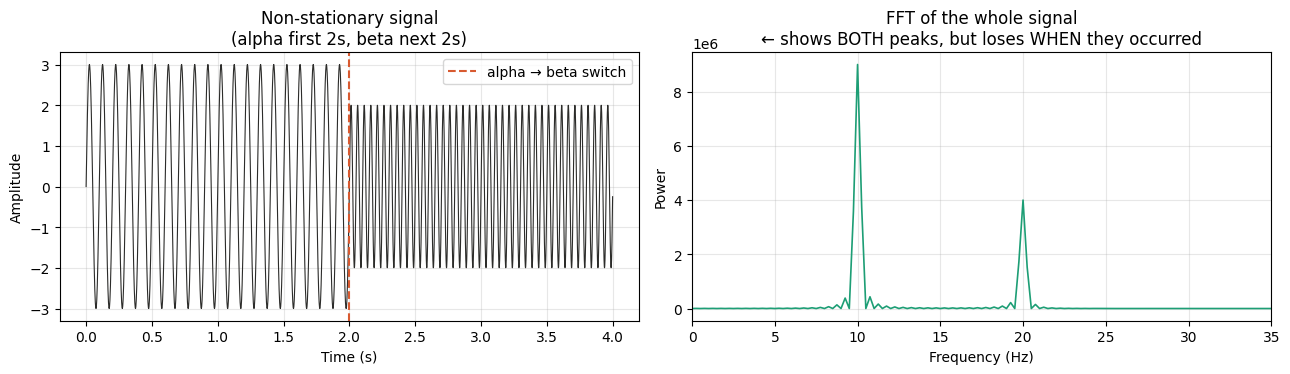

PROBLEM: The FFT shows peaks at 10 Hz AND 20 Hz.
But it cannot tell us: "alpha was in the first half, beta in the second half."

This is the stationarity problem. Solution → time-frequency analysis (Session 15).
Wavelets give us BOTH: which frequency AND when it appeared.


In [ ]:
# Demonstrate non-stationarity
# Signal: 10 Hz alpha for first 2 seconds, then 20 Hz beta for next 2 seconds

t_long = np.linspace(0, 4, sfreq * 4, endpoint=False)

# Non-stationary signal: alpha switches to beta at t=2s
nonstat = np.concatenate([
    3.0 * np.sin(2 * np.pi * 10 * t_long[:sfreq*2]),   # first 2s: alpha
    2.0 * np.sin(2 * np.pi * 20 * t_long[:sfreq*2])    # next 2s: beta
])

# FFT of the whole signal
freqs_long = np.fft.rfftfreq(len(nonstat), d=1/sfreq)
power_long = np.abs(np.fft.rfft(nonstat)) ** 2

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t_long, nonstat, color='#2C2C2A', linewidth=0.8)
axes[0].axvline(2, color='#D85A30', linewidth=1.5, linestyle='--', label='alpha → beta switch')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Non-stationary signal\n(alpha first 2s, beta next 2s)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_long, power_long, color='#1D9E75', linewidth=1.2)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Power')
axes[1].set_xlim(0, 35)
axes[1].set_title('FFT of the whole signal\n← shows BOTH peaks, but loses WHEN they occurred')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('PROBLEM: The FFT shows peaks at 10 Hz AND 20 Hz.')
print('But it cannot tell us: "alpha was in the first half, beta in the second half."')
print()
print('This is the stationarity problem. Solution → time-frequency analysis (Session 15).')
print('Wavelets give us BOTH: which frequency AND when it appeared.')

---
## Part C: PSD in MNE on Real EEG Data

Now we apply everything above to your actual preprocessed epochs from Session 13.

### Welch method.. why not just use FFT directly?

Raw FFT on a single trial is noisy. The **Welch method** fixes this:
1. Split the signal into overlapping windows
2. Compute FFT on each window
3. Average the power spectra across windows

Result: a much smoother, more reliable power spectrum estimate.

In [ ]:
# Load your preprocessed epochs from Session 13
# Replace this path with the actual path to your saved .fif file

# Option 1: if you saved to Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# epochs_path = '/content/S007_R04_clean_epo.fif'

# Option 2: fallback — use MNE sample data if you don't have your epochs yet
print('Loading epochs...')
print('NOTE: Replace the lines below with your actual file path from Session 13')

try:
    # Try loading YOUR epochs first
    epochs = mne.read_epochs('S007_R04_clean_epo.fif', preload=True)
    print(f'Loaded YOUR epochs: {len(epochs)} epochs')
    #raise FileNotFoundError  # remove this line once you have your file

except FileNotFoundError:
    print('Using MNE sample data as fallback...')
    from mne.datasets import sample
    data_path = sample.data_path()
    raw = mne.io.read_raw_fif(
        data_path / 'MEG' / 'sample' / 'sample_audvis_raw.fif',
        preload=True, verbose=False
    )
    raw.pick_types(meg=False, eeg=True, stim=True)
    raw.filter(1.0, 40.0, verbose=False)
    events = mne.find_events(raw, verbose=False)
    epochs = mne.Epochs(
        raw, events, event_id={'auditory/left': 1, 'auditory/right': 2},
        tmin=-0.2, tmax=0.8, baseline=(-0.2, 0),
        reject=dict(eeg=150e-6), preload=True, verbose=False
    )
    print(f'Fallback epochs loaded: {len(epochs)} epochs, {len(epochs.ch_names)} channels')
    print(f'Sampling rate: {epochs.info["sfreq"]} Hz')

Loading epochs...
NOTE: Replace the lines below with your actual file path from Session 13
Loaded YOUR epochs: 24 epochs


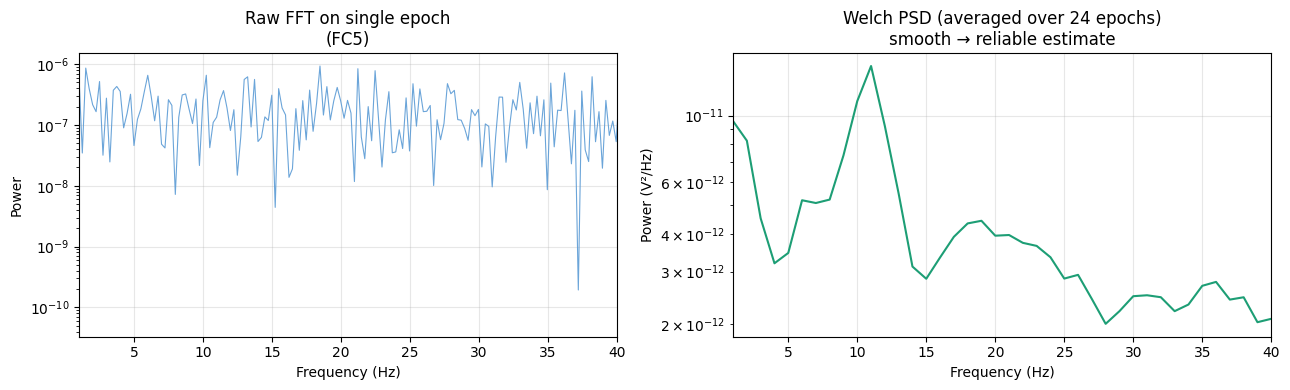

Welch is smoother because it averages many FFT windows.
This is almost always what you want for EEG analysis.


In [ ]:
# Welch vs raw FFT: see the difference

# Pick one channel and one epoch
ch_idx = 0
one_epoch = epochs.get_data()[0, ch_idx, :]  # shape: (n_times,)
sfreq = epochs.info['sfreq']
freqs_raw = np.fft.rfftfreq(len(one_epoch), d=1/sfreq)
power_raw = np.abs(np.fft.rfft(one_epoch)) ** 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Raw FFT on single epoch
ax1.plot(freqs_raw, power_raw, color='#5B9BD5', linewidth=0.8, alpha=0.9)
ax1.set_xlim(1, 40)
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Power')
ax1.set_title(f'Raw FFT on single epoch\n({epochs.ch_names[ch_idx]})')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Welch PSD averaged over all epochs
psd = epochs.compute_psd(method='welch', fmin=1, fmax=40,
                          n_fft=int(sfreq * 1),  # 1-second windows
                          n_overlap=int(sfreq * 0.5))

# Get data for same channel
psd_data, psd_freqs = psd.get_data(return_freqs=True)
mean_power = psd_data[:, ch_idx, :].mean(axis=0)  # average over epochs

ax2.plot(psd_freqs, mean_power, color='#1D9E75', linewidth=1.5)
ax2.set_xlim(1, 40)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Power (V²/Hz)')
ax2.set_title(f'Welch PSD (averaged over {len(epochs)} epochs)\nsmooth → reliable estimate')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

print('Welch is smoother because it averages many FFT windows.')
print('This is almost always what you want for EEG analysis.')

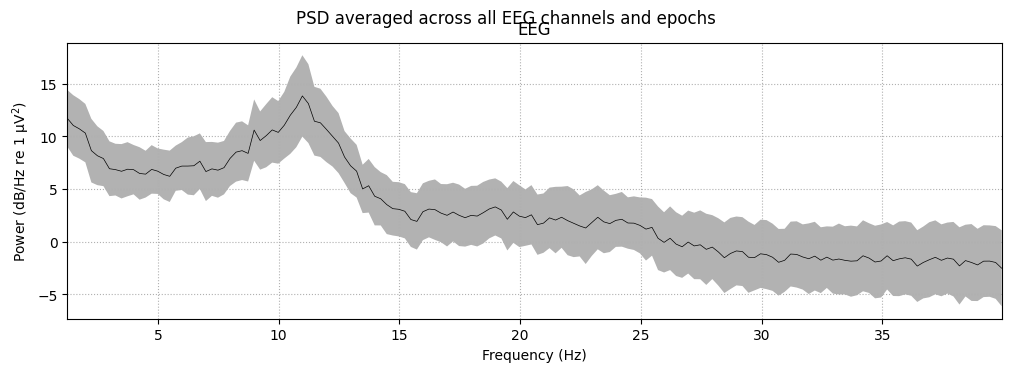

What to look for:
  ✓ 1/f slope: more power at lower frequencies — this is normal for EEG
  ✓ Alpha peak (~10 Hz): bump above the 1/f line — healthy resting alpha
  ✗ Sharp spike at 50 or 60 Hz: line noise — should have been removed by notch filter
  ✗ Elevated power above 30 Hz: residual muscle artifact


In [ ]:
# MNE's built-in PSD plot

psd = epochs.compute_psd(method='welch', fmin=1, fmax=40)
fig = psd.plot(average=True, picks='eeg')
fig.suptitle('PSD averaged across all EEG channels and epochs', y=1.02)
plt.show()

print('What to look for:')
print('  ✓ 1/f slope: more power at lower frequencies — this is normal for EEG')
print('  ✓ Alpha peak (~10 Hz): bump above the 1/f line — healthy resting alpha')
print('  ✗ Sharp spike at 50 or 60 Hz: line noise — should have been removed by notch filter')
print('  ✗ Elevated power above 30 Hz: residual muscle artifact')

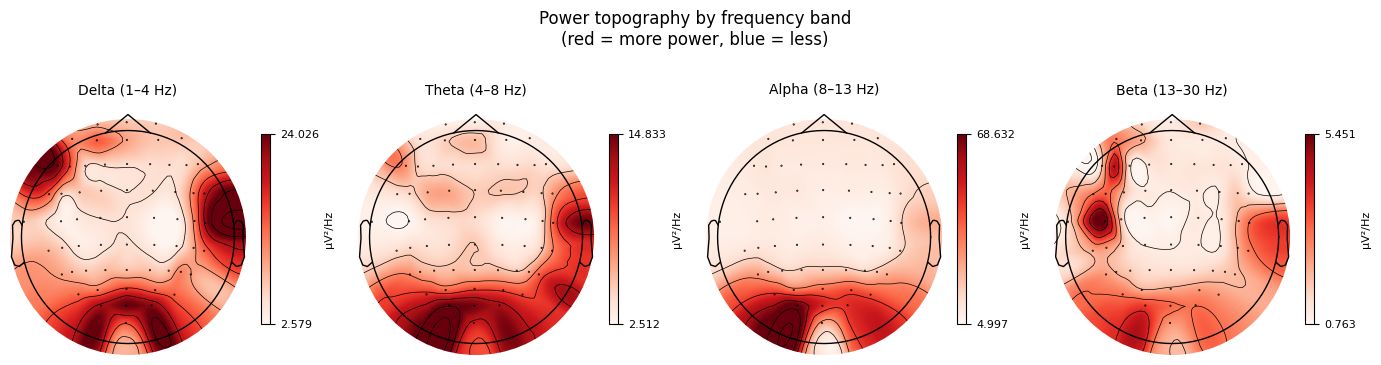

Expected patterns (if the data is clean):
  Alpha (8-13 Hz): strongest over occipital channels (O1, Oz, O2)
  Beta  (13-30 Hz): stronger over frontal/central channels
  Delta (1-4 Hz):  should be low during wakefulness (if high → drowsy participant or artifact)


In [ ]:
# WHERE are these frequencies? Topographic maps by band

bands = {
    'Delta (1–4 Hz)':  (1, 4),
    'Theta (4–8 Hz)':  (4, 8),
    'Alpha (8–13 Hz)': (8, 13),
    'Beta (13–30 Hz)': (13, 30),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

psd_topomap = epochs.compute_psd(method='welch', fmin=1, fmax=40)

for ax, (band_name, (fmin, fmax)) in zip(axes, bands.items()):
    psd_topomap.plot_topomap(
        bands={band_name: (fmin, fmax)},
        axes=ax,
        show=False
    )
    ax.set_title(band_name, fontsize=10)

fig.suptitle('Power topography by frequency band\n(red = more power, blue = less)', fontsize=12)
plt.tight_layout()
plt.show()

print('Expected patterns (if the data is clean):')
print('  Alpha (8-13 Hz): strongest over occipital channels (O1, Oz, O2)')
print('  Beta  (13-30 Hz): stronger over frontal/central channels')
print('  Delta (1-4 Hz):  should be low during wakefulness (if high → drowsy participant or artifact)')

Conditions in dataset: ['rest/T0', 'movement/left_fist', 'movement/right_fist']


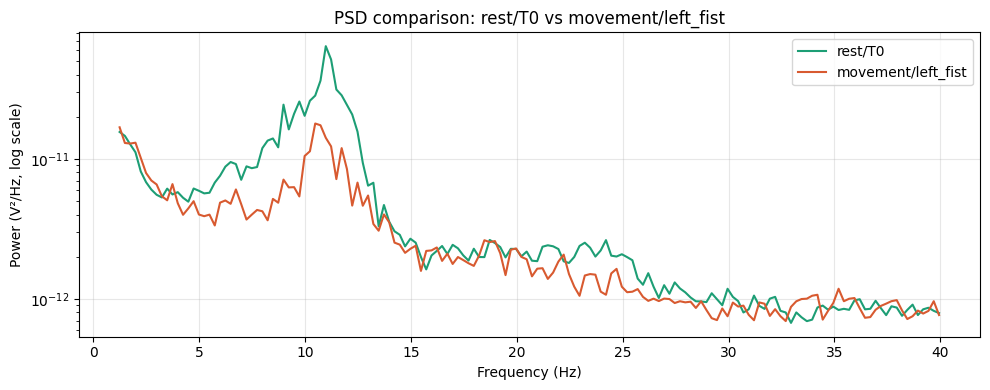

Do the two conditions differ at any frequency band?
→ Note your observations below this cell as a comment.


In [ ]:
# Compare PSD across conditions
# Are there frequency differences between conditions?

conditions = list(epochs.event_id.keys())
print(f'Conditions in dataset: {conditions}')

if len(conditions) >= 2:
    cond_a = conditions[0]
    cond_b = conditions[1]

    psd_a = epochs[cond_a].compute_psd(method='welch', fmin=1, fmax=40)
    psd_b = epochs[cond_b].compute_psd(method='welch', fmin=1, fmax=40)

    fig, ax = plt.subplots(figsize=(10, 4))

    for psd_obj, label, color in [
        (psd_a, cond_a, '#1D9E75'),
        (psd_b, cond_b, '#D85A30')
    ]:
        data, freqs_c = psd_obj.get_data(return_freqs=True)
        mean_p = data.mean(axis=(0, 1))  # average over epochs and channels
        ax.semilogy(freqs_c, mean_p, label=label, color=color, linewidth=1.5)

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power (V²/Hz, log scale)')
    ax.set_title(f'PSD comparison: {cond_a} vs {cond_b}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('Do the two conditions differ at any frequency band?')
else:
    print('Only one condition found. Plotting single PSD.')
    psd_a = epochs.compute_psd(method='welch', fmin=1, fmax=40)
    psd_a.plot(average=True)
    plt.show()

---
## Summary: what to remember

| Concept | One-line version |
|---|---|
| Fourier transform | Decomposes any signal into sine waves; output = power at each frequency |
| Power spectrum | Power (amplitude²) vs frequency. Tells you *what rhythms* are in the signal |
| Frequency resolution | 1 / duration. Longer signal = finer frequency detail |
| Nyquist limit | Max frequency = sfreq / 2. Sampling rate sets the ceiling |
| Welch method | Average FFTs across overlapping windows → smoother, more reliable PSD |
| Stationarity problem | FFT assumes frequencies are constant over time |
| Fix | Time-frequency analysis (wavelets). Gives power at each *time AND frequency* |